--- Run with step size h = 0.01 ---
Point-by-point errors (first 5): [0. 0. 0. 0. 0.]
Total accumulated error: 0.0000

--- Run with step size h = 0.06 ---
Point-by-point errors (first 5): [0.     0.0058 0.0103 0.0137 0.0161]
Total accumulated error: 0.3923

--- Run with step size h = 0.11 ---
Point-by-point errors (first 5): [0.     0.0207 0.0328 0.0389 0.0409]
Total accumulated error: 0.4398

--- Run with step size h = 0.16 ---
Point-by-point errors (first 5): [0.     0.0438 0.0615 0.0648 0.0606]
Total accumulated error: 0.4621

--- Run with step size h = 0.21 ---
Point-by-point errors (first 5): [0.     0.0743 0.0917 0.0849 0.0701]
Total accumulated error: 0.4801

--- Run with step size h = 0.26 ---
Point-by-point errors (first 5): [0.     0.1114 0.1193 0.0962 0.0692]
Total accumulated error: 0.4931

--- Run with step size h = 0.31 ---
Point-by-point errors (first 5): [0.     0.1546 0.1414 0.0979 0.0608]
Total accumulated error: 0.5107

--- Run with step size h = 0.36 ---
Point-by-po

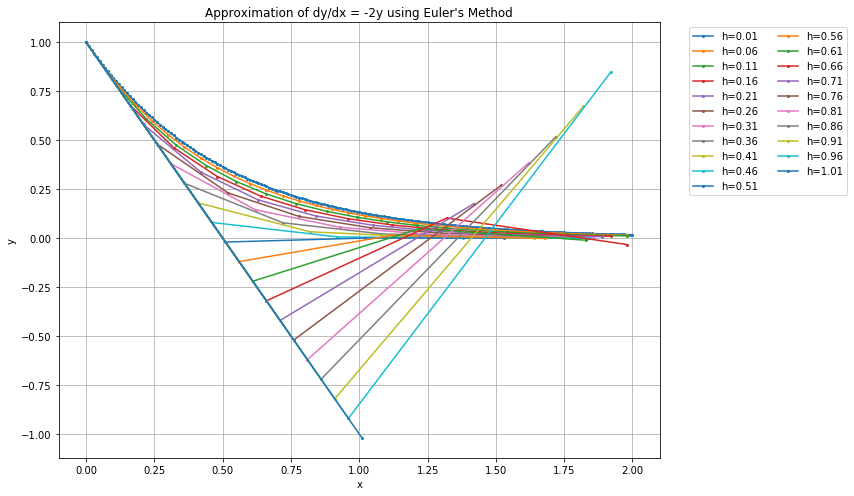

In [4]:
import numpy as np
import matplotlib.pyplot as plt

x_start, x_end = 0, 2

def f(x, y):
    return -2 * y

y_base = None
plt.figure(figsize=(12, 7))

# Loop from 1 to 101 in steps of 5. 
# Divided by 100, this gives h = 0.01, 0.06, 0.11 ... 1.01
for step_multiplier in range(1, 105, 5):
    h = step_multiplier / 100.0
    
    # We use arange instead of linspace to guarantee 'h' is strictly respected
    x_values = np.arange(x_start, x_end + 1e-9, h)
    num_steps = len(x_values) - 1
    y_values = np.zeros(num_steps + 1)
    
    y_values[0] = 1
    
    for i in range(num_steps):
        y_values[i + 1] = y_values[i] + h * f(x_values[i], y_values[i])
        
    if y_base is None:
        # Save the very first run (h=0.01) as the baseline
        y_base = y_values
        
    # EXACT point-by-point error comparison
    # Since 'h' is a multiple of 0.01, we pull every nth element from the baseline
    # using array slicing (::step_multiplier) to get the exact overlapping points!
    y_base_matching_points = y_base[::step_multiplier][:len(y_values)]
    
    point_errors = np.abs(y_values - y_base_matching_points)
    total_error = np.sum(point_errors)
    
    print(f"--- Run with step size h = {h:.2f} ---")
    # Limiting the print to the first 5 errors so we don't flood your console
    print(f"Point-by-point errors (first 5): {np.round(point_errors[:5], 4)}")
    print(f"Total accumulated error: {total_error:.4f}\n")
    
    plt.plot(x_values, y_values, marker='.', markersize=4, label=f"h={h:.2f}")

plt.xlabel('x')
plt.ylabel('y')
plt.title("Approximation of dy/dx = -2y using Euler's Method")
plt.legend(bbox_to_anchor=(1.04, 1), loc="upper left", ncol=2) 
plt.grid(True)
plt.tight_layout()
plt.show()